# 🫁 Liver Disease Dataset - Exploratory Data Analysis

## Multi-Disease AI Healthcare Platform | BTP 2025-2026

---

### 📋 Notebook Overview

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the **Liver Disease Dataset** to understand data quality, feature distributions, and preprocessing requirements.

### 🎯 Objectives
1. Understand dataset structure and feature types
2. Identify missing values and their patterns
3. Analyze class distribution (liver disease vs healthy)
4. Detect outliers and anomalies
5. Explore feature correlations
6. Generate preprocessing recommendations for Week 3

### 📊 Dataset Information
- **Source:** Indian Liver Patient Dataset (Extended)
- **Size:** ~30,691 patient records
- **Target:** `Result` (1 = Liver Disease, 2 = No Liver Disease)
- **Features:** Demographics, liver function tests (LFTs)

### 📝 Key Liver Function Tests (LFTs)
- **Bilirubin:** Waste product from red blood cell breakdown
- **Alkaline Phosphatase (ALP):** Enzyme found in liver and bones
- **ALT (SGPT):** Enzyme specific to liver damage
- **AST (SGOT):** Enzyme found in liver, heart, muscles
- **Albumin:** Protein made by liver
- **A/G Ratio:** Albumin to Globulin ratio

---

**Author:** BTP Project Team  
**Date:** January 27, 2026  
**Week:** 2 - Exploratory Data Analysis

## 1. Setup and Data Loading

In [1]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Add project root to path for imports
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))

# Import our EDA utilities
from src.utils.eda_utils import (
    load_dataset, missing_value_analysis, statistical_summary,
    class_distribution_analysis, distribution_plots, outlier_analysis,
    correlation_analysis, feature_type_analysis, generate_eda_report,
    COLORS
)

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paths
DATA_PATH = Path('../../datasets/liver_disease_30k.csv')
FIGURES_PATH = Path('./figures/liver_disease')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Figures will be saved to: {FIGURES_PATH}")

✅ Libraries imported successfully!
📁 Data path: ..\..\datasets\liver_disease_30k.csv
📁 Figures will be saved to: figures\liver_disease


In [2]:
# ============================================================================
# LOAD DATASET
# ============================================================================

df = load_dataset(DATA_PATH)

# Display first few rows
print("\n📋 First 5 rows of the dataset:")
df.head()

📊 DATASET OVERVIEW
📁 File: liver_disease_30k.csv
📐 Shape: 30,691 rows × 11 columns
💾 Memory Usage: 4.12 MB
🔢 Numeric Columns: 10
📝 Categorical Columns: 1

📋 First 5 rows of the dataset:


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.000,Female,0.700,0.100,187.000,16.000,18.000,6.800,3.300,0.900,1
1,62.000,Male,10.900,5.500,699.000,64.000,100.000,7.500,3.200,0.740,1
2,62.000,Male,7.300,4.100,490.000,60.000,68.000,7.000,3.300,0.890,1
3,58.000,Male,1.000,0.400,182.000,14.000,20.000,6.800,3.400,1.000,1
4,72.000,Male,3.900,2.000,195.000,27.000,59.000,7.300,2.400,0.400,1


In [3]:
# ============================================================================
# COLUMN INFORMATION
# ============================================================================

print("📋 COLUMN DESCRIPTIONS")
print("=" * 90)

column_descriptions = {
    'Age of the patient': 'Age in years',
    'Gender of the patient': 'Gender (Male/Female)',
    'Total Bilirubin': 'Total bilirubin (mg/dL) - waste product, elevated in liver disease',
    'Direct Bilirubin': 'Direct (conjugated) bilirubin (mg/dL)',
    'Alkphos Alkaline Phosphotase': 'Alkaline Phosphatase (IU/L) - liver/bone enzyme',
    'Sgpt Alamine Aminotransferase': 'ALT/SGPT (IU/L) - 🔑 KEY liver damage marker',
    'Sgot Aspartate Aminotransferase': 'AST/SGOT (IU/L) - liver, heart, muscle enzyme',
    'Total Protiens': 'Total proteins (g/dL)',
    'ALB Albumin': 'Albumin (g/dL) - protein made by liver',
    'A/G Ratio Albumin and Globulin Ratio': 'A/G Ratio - liver synthetic function indicator',
    'Result': '🎯 TARGET: 1 = Liver Disease, 2 = No Liver Disease'
}

for col in df.columns:
    desc = column_descriptions.get(col, 'No description available')
    dtype = df[col].dtype
    print(f"• {col:45} ({str(dtype):8}): {desc}")

📋 COLUMN DESCRIPTIONS
• Age of the patient                            (float64 ): Age in years
• Gender of the patient                         (object  ): Gender (Male/Female)
• Total Bilirubin                               (float64 ): Total bilirubin (mg/dL) - waste product, elevated in liver disease
• Direct Bilirubin                              (float64 ): Direct (conjugated) bilirubin (mg/dL)
• Alkphos Alkaline Phosphotase                  (float64 ): Alkaline Phosphatase (IU/L) - liver/bone enzyme
• Sgpt Alamine Aminotransferase                 (float64 ): ALT/SGPT (IU/L) - 🔑 KEY liver damage marker
• Sgot Aspartate Aminotransferase               (float64 ): AST/SGOT (IU/L) - liver, heart, muscle enzyme
• Total Protiens                                (float64 ): Total proteins (g/dL)
• ALB Albumin                                   (float64 ): Albumin (g/dL) - protein made by liver
• A/G Ratio Albumin and Globulin Ratio          (float64 ): A/G Ratio - liver synthetic function ind

In [4]:
# ============================================================================
# RENAME COLUMNS FOR EASIER USE
# ============================================================================

print("🔄 RENAMING COLUMNS FOR EASIER ANALYSIS")
print("=" * 50)

column_mapping = {
    'Age of the patient': 'Age',
    'Gender of the patient': 'Gender',
    'Total Bilirubin': 'Total_Bilirubin',
    'Direct Bilirubin': 'Direct_Bilirubin',
    'Alkphos Alkaline Phosphotase': 'ALP',
    'Sgpt Alamine Aminotransferase': 'ALT_SGPT',
    'Sgot Aspartate Aminotransferase': 'AST_SGOT',
    'Total Protiens': 'Total_Proteins',
    'ALB Albumin': 'Albumin',
    'A/G Ratio Albumin and Globulin Ratio': 'AG_Ratio',
    'Result': 'Result'
}

df = df.rename(columns=column_mapping)

print("\nNew column names:")
for old, new in column_mapping.items():
    print(f"   {old} → {new}")

print(f"\n✅ Columns renamed successfully!")
df.head()

🔄 RENAMING COLUMNS FOR EASIER ANALYSIS

New column names:
   Age of the patient → Age
   Gender of the patient → Gender
   Total Bilirubin → Total_Bilirubin
   Direct Bilirubin → Direct_Bilirubin
   Alkphos Alkaline Phosphotase → ALP
   Sgpt Alamine Aminotransferase → ALT_SGPT
   Sgot Aspartate Aminotransferase → AST_SGOT
   Total Protiens → Total_Proteins
   ALB Albumin → Albumin
   A/G Ratio Albumin and Globulin Ratio → AG_Ratio
   Result → Result

✅ Columns renamed successfully!


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,ALP,ALT_SGPT,AST_SGOT,Total_Proteins,Albumin,AG_Ratio,Result
0,65.000,Female,0.700,0.100,187.000,16.000,18.000,6.800,3.300,0.900,1
1,62.000,Male,10.900,5.500,699.000,64.000,100.000,7.500,3.200,0.740,1
2,62.000,Male,7.300,4.100,490.000,60.000,68.000,7.000,3.300,0.890,1
3,58.000,Male,1.000,0.400,182.000,14.000,20.000,6.800,3.400,1.000,1
4,72.000,Male,3.900,2.000,195.000,27.000,59.000,7.300,2.400,0.400,1


## 2. Data Quality Assessment

In [5]:
# ============================================================================
# DATA TYPES AND INFO
# ============================================================================

print("📊 DATA TYPES OVERVIEW")
print("=" * 50)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Data Types:")
print(df.dtypes)

print(f"\n💾 Total Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 DATA TYPES OVERVIEW

Dataset Shape: (30691, 11)

Column Data Types:
Age                 float64
Gender               object
Total_Bilirubin     float64
Direct_Bilirubin    float64
ALP                 float64
ALT_SGPT            float64
AST_SGOT            float64
Total_Proteins      float64
Albumin             float64
AG_Ratio            float64
Result                int64
dtype: object

💾 Total Memory Usage: 4.12 MB



🔍 MISSING VALUE ANALYSIS
📊 Total Cells: 337,601
❌ Total Missing: 5,425
📈 Overall Missing Rate: 1.61%
📋 Columns with Missing Values: 10/11


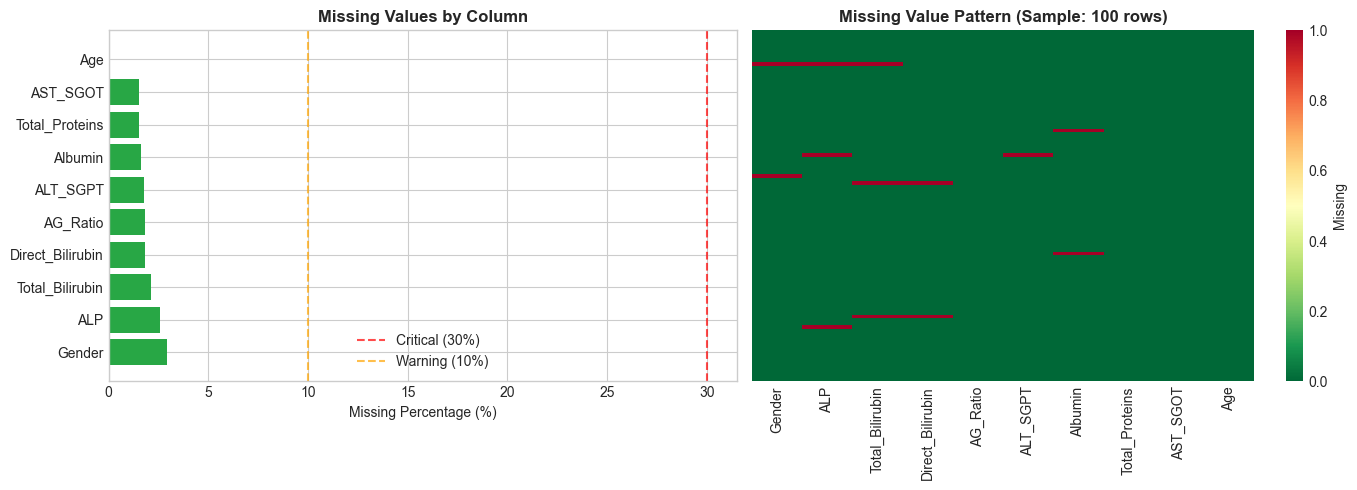

In [6]:
# ============================================================================
# MISSING VALUE ANALYSIS
# ============================================================================

missing_stats = missing_value_analysis(df, plot=True, figsize=(14, 5))

In [7]:
# ============================================================================
# CHECK FOR DUPLICATE RECORDS
# ============================================================================

print("🔍 DUPLICATE ANALYSIS")
print("=" * 50)

duplicates = df.duplicated().sum()
dup_pct = (duplicates / len(df)) * 100

print(f"📋 Total Records: {len(df):,}")
print(f"🔄 Duplicate Records: {duplicates:,} ({dup_pct:.2f}%)")

if duplicates > 0:
    print(f"⚠️  Consider removing duplicates during preprocessing.")
else:
    print(f"✅ No duplicate records found.")

🔍 DUPLICATE ANALYSIS
📋 Total Records: 30,691
🔄 Duplicate Records: 11,323 (36.89%)
⚠️  Consider removing duplicates during preprocessing.


In [8]:
# ============================================================================
# FIX TARGET COLUMN ENCODING
# ============================================================================

print("🎯 TARGET COLUMN ANALYSIS")
print("=" * 50)

print(f"\nOriginal Target Values:")
print(df['Result'].value_counts())

# Note: In this dataset:
# 1 = Liver Disease
# 2 = No Liver Disease
# We'll remap to standard: 0 = No Disease, 1 = Disease

print("\n⚠️ NOTE: Target encoding is non-standard!")
print("   Current: 1 = Disease, 2 = No Disease")
print("   Will convert to: 0 = No Disease, 1 = Disease during preprocessing")

# Create a binary column for analysis (keeping original for reference)
df['liver_disease'] = df['Result'].apply(lambda x: 1 if x == 1 else 0)

print(f"\nNew binary target (liver_disease):")
print(df['liver_disease'].value_counts())

🎯 TARGET COLUMN ANALYSIS

Original Target Values:
Result
1    21917
2     8774
Name: count, dtype: int64

⚠️ NOTE: Target encoding is non-standard!
   Current: 1 = Disease, 2 = No Disease
   Will convert to: 0 = No Disease, 1 = Disease during preprocessing

New binary target (liver_disease):
liver_disease
1    21917
0     8774
Name: count, dtype: int64


## 3. Statistical Summary

In [9]:
# ============================================================================
# COMPREHENSIVE STATISTICAL SUMMARY
# ============================================================================

stats = statistical_summary(df)
stats


📈 STATISTICAL SUMMARY
📊 Numeric Features: 11
⚠️  Highly Skewed Features (|skew| > 1): 6


,Count,Mean,Std,Min,Q1 (25%),Median,Q3 (75%),Max,Skewness,Kurtosis,IQR
Age,30689,44.107,15.981,4.000,32.000,45.000,55.000,90.000,0.028,-0.488,23.000
Total_Bilirubin,30043,3.370,6.256,0.400,0.800,1.000,2.700,75.000,4.665,33.427,1.900
Direct_Bilirubin,30130,1.528,2.870,0.100,0.200,0.300,1.300,19.700,3.157,10.878,1.100
ALP,29895,289.075,238.538,63.000,175.000,209.000,298.000,2110.000,3.778,17.991,123.000
ALT_SGPT,30153,81.489,182.159,10.000,23.000,35.000,62.000,2000.000,6.456,49.196,39.000
AST_SGOT,30229,111.470,280.851,10.000,26.000,42.000,88.000,4929.000,10.345,149.363,62.000
Total_Proteins,30228,6.480,1.082,2.700,5.800,6.600,7.200,9.600,-0.291,0.206,1.400
Albumin,30197,3.130,0.792,0.900,2.600,3.100,3.800,5.500,-0.039,-0.390,1.200
AG_Ratio,30132,0.943,0.323,0.300,0.700,0.900,1.100,2.800,1.058,3.544,0.400
Result,30691,1.286,0.452,1.000,1.000,1.000,2.000,2.000,0.948,-1.102,1.000


In [10]:
# ============================================================================
# LIVER FUNCTION TEST (LFT) REFERENCE RANGES
# ============================================================================

print("🩺 LIVER FUNCTION TEST (LFT) ANALYSIS")
print("=" * 70)

# Normal reference ranges for LFTs
lft_ranges = {
    'Total_Bilirubin': {'normal': (0.1, 1.2), 'unit': 'mg/dL', 'desc': 'Elevated in jaundice, liver disease'},
    'Direct_Bilirubin': {'normal': (0.0, 0.3), 'unit': 'mg/dL', 'desc': 'Elevated in biliary obstruction'},
    'ALP': {'normal': (44, 147), 'unit': 'IU/L', 'desc': 'Elevated in cholestasis, bone disease'},
    'ALT_SGPT': {'normal': (7, 56), 'unit': 'IU/L', 'desc': '🔑 Most specific for liver damage'},
    'AST_SGOT': {'normal': (10, 40), 'unit': 'IU/L', 'desc': 'Elevated in liver, heart, muscle damage'},
    'Total_Proteins': {'normal': (6.0, 8.3), 'unit': 'g/dL', 'desc': 'Low in chronic liver disease'},
    'Albumin': {'normal': (3.5, 5.0), 'unit': 'g/dL', 'desc': 'Low in liver dysfunction'},
    'AG_Ratio': {'normal': (1.0, 2.5), 'unit': 'ratio', 'desc': 'Low in cirrhosis'}
}

print("\n📊 LFT Values vs Normal Ranges:")
print("-" * 70)

for marker, info in lft_ranges.items():
    if marker in df.columns:
        data = df[marker].dropna()
        normal_range = info['normal']
        
        # Calculate percentages
        below_normal = (data < normal_range[0]).mean() * 100
        normal = ((data >= normal_range[0]) & (data <= normal_range[1])).mean() * 100
        above_normal = (data > normal_range[1]).mean() * 100
        
        print(f"\n🔬 {marker}:")
        print(f"   Normal Range: {normal_range[0]}-{normal_range[1]} {info['unit']}")
        print(f"   Our Data: Min={data.min():.2f}, Max={data.max():.2f}, Mean={data.mean():.2f}")
        print(f"   Below Normal: {below_normal:.1f}% | Normal: {normal:.1f}% | Above Normal: {above_normal:.1f}%")
        print(f"   Clinical Note: {info['desc']}")

🩺 LIVER FUNCTION TEST (LFT) ANALYSIS

📊 LFT Values vs Normal Ranges:
----------------------------------------------------------------------

🔬 Total_Bilirubin:
   Normal Range: 0.1-1.2 mg/dL
   Our Data: Min=0.40, Max=75.00, Mean=3.37
   Below Normal: 0.0% | Normal: 56.5% | Above Normal: 43.5%
   Clinical Note: Elevated in jaundice, liver disease

🔬 Direct_Bilirubin:
   Normal Range: 0.0-0.3 mg/dL
   Our Data: Min=0.10, Max=19.70, Mean=1.53
   Below Normal: 0.0% | Normal: 52.3% | Above Normal: 47.7%
   Clinical Note: Elevated in biliary obstruction

🔬 ALP:
   Normal Range: 44-147 IU/L
   Our Data: Min=63.00, Max=2110.00, Mean=289.08
   Below Normal: 0.0% | Normal: 9.5% | Above Normal: 90.5%
   Clinical Note: Elevated in cholestasis, bone disease

🔬 ALT_SGPT:
   Normal Range: 7-56 IU/L
   Our Data: Min=10.00, Max=2000.00, Mean=81.49
   Below Normal: 0.0% | Normal: 71.7% | Above Normal: 28.3%
   Clinical Note: 🔑 Most specific for liver damage

🔬 AST_SGOT:
   Normal Range: 10-40 IU/L
   O

## 4. Target Variable Analysis


⚖️ CLASS DISTRIBUTION ANALYSIS
🎯 Target Column: liver_disease
📊 Number of Classes: 2

📈 Class Distribution:
   • Class 1: 21,917 samples (71.41%)
   • Class 0: 8,774 samples (28.59%)

⚖️ Imbalance Ratio: 2.50:1
⚡ MODERATE IMBALANCE. May need handling during training.


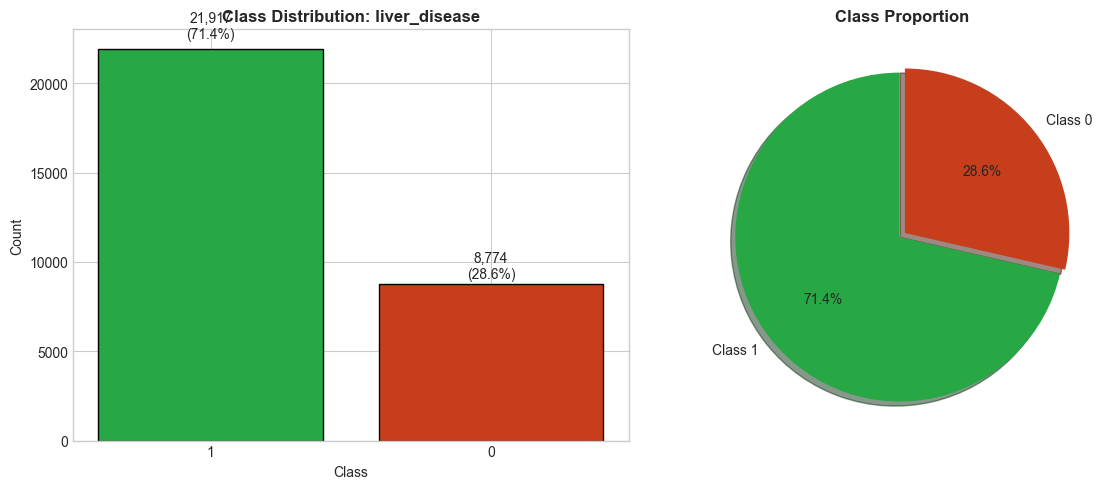


📁 Figure saved to: figures\liver_disease\class_distribution.png


<Figure size 640x480 with 0 Axes>

In [11]:
# ============================================================================
# CLASS DISTRIBUTION (Using binary target)
# ============================================================================

class_info = class_distribution_analysis(df, target_col='liver_disease', figsize=(12, 5))

plt.savefig(FIGURES_PATH / 'class_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'class_distribution.png'}")

## 5. Feature Type Analysis

In [12]:
# ============================================================================
# CATEGORIZE FEATURES BY TYPE
# ============================================================================

feature_types = feature_type_analysis(df)


📋 FEATURE TYPE ANALYSIS

📌 CONTINUOUS (9 features):
   Age, Total_Bilirubin, Direct_Bilirubin, ALP, ALT_SGPT, AST_SGOT, Total_Proteins, Albumin, AG_Ratio

📌 BINARY (2 features):
   Result, liver_disease

📌 CATEGORICAL (1 features):
   Gender



📊 GENDER DISTRIBUTION


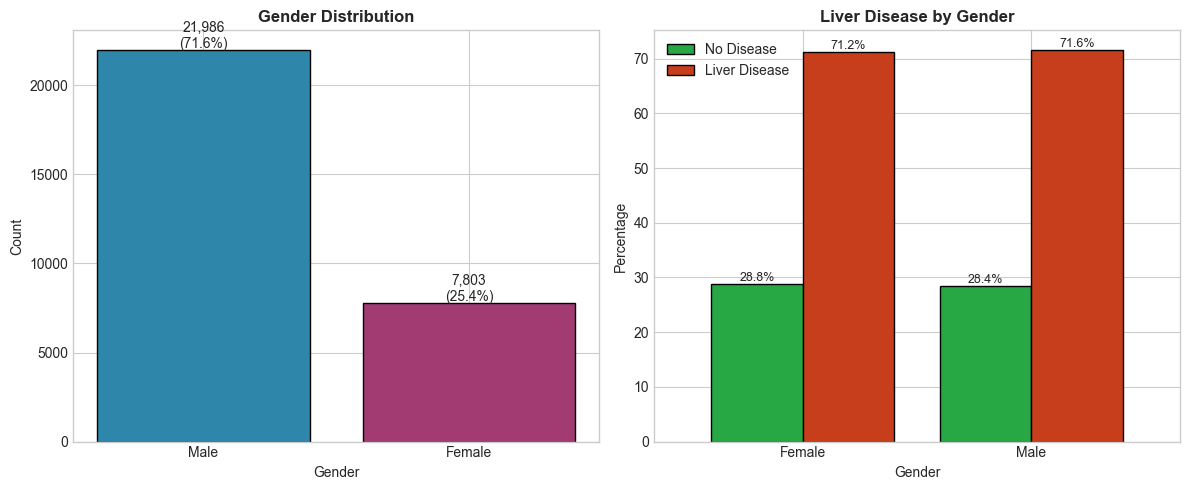


📊 Gender Distribution:
   Male: 21,986 (71.6%) - Liver Disease Rate: 71.6%
   Female: 7,803 (25.4%) - Liver Disease Rate: 71.2%


In [13]:
# ============================================================================
# GENDER DISTRIBUTION
# ============================================================================

print("📊 GENDER DISTRIBUTION")
print("=" * 50)

if 'Gender' in df.columns:
    gender_counts = df['Gender'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gender distribution
    ax1 = axes[0]
    colors = [COLORS['primary'], COLORS['secondary']]
    ax1.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black')
    ax1.set_xlabel('Gender')
    ax1.set_ylabel('Count')
    ax1.set_title('Gender Distribution', fontsize=12, fontweight='bold')
    
    for i, (idx, count) in enumerate(gender_counts.items()):
        ax1.text(i, count + 100, f'{count:,}\n({count/len(df)*100:.1f}%)', 
                ha='center', fontsize=10)
    
    # Gender vs Liver Disease
    ax2 = axes[1]
    crosstab = pd.crosstab(df['Gender'], df['liver_disease'], normalize='index') * 100
    crosstab.plot(kind='bar', ax=ax2, color=[COLORS['success'], COLORS['danger']], 
                  edgecolor='black', width=0.8)
    ax2.set_xlabel('Gender')
    ax2.set_ylabel('Percentage')
    ax2.set_title('Liver Disease by Gender', fontsize=12, fontweight='bold')
    ax2.legend(['No Disease', 'Liver Disease'])
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
    
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.1f%%', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'gender_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\n📊 Gender Distribution:")
    for gender, count in gender_counts.items():
        pct = count / len(df) * 100
        disease_rate = df[df['Gender'] == gender]['liver_disease'].mean() * 100
        print(f"   {gender}: {count:,} ({pct:.1f}%) - Liver Disease Rate: {disease_rate:.1f}%")

## 6. Continuous Feature Distributions


📊 FEATURE DISTRIBUTIONS


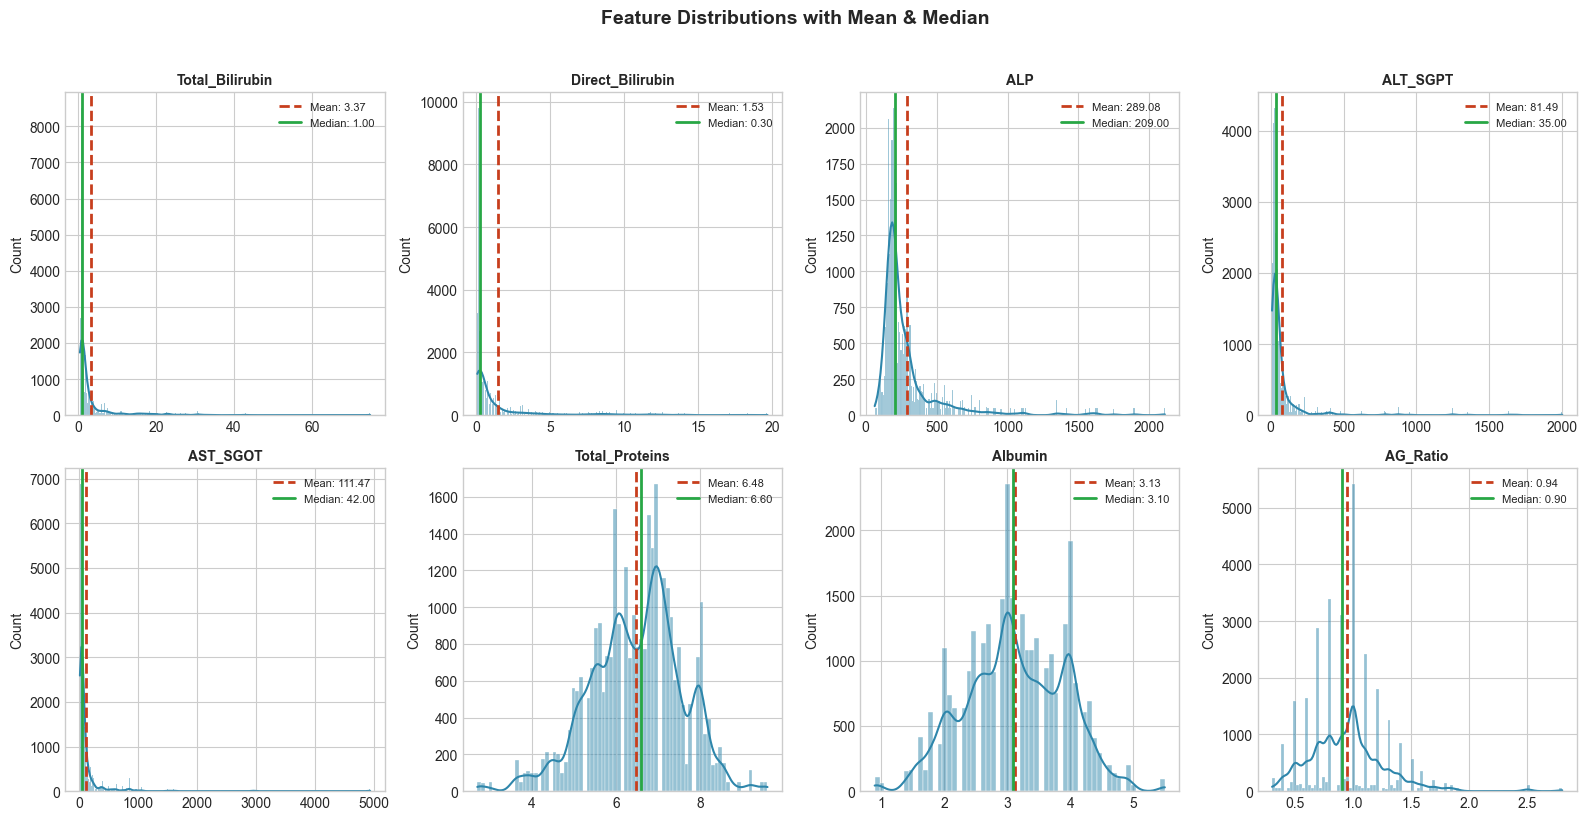

<Figure size 640x480 with 0 Axes>

In [14]:
# ============================================================================
# LFT DISTRIBUTIONS
# ============================================================================

lft_cols = ['Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT_SGPT', 
            'AST_SGOT', 'Total_Proteins', 'Albumin', 'AG_Ratio']

lft_cols = [col for col in lft_cols if col in df.columns]

distribution_plots(df, columns=lft_cols, n_cols=4, figsize=(16, 8))

plt.savefig(FIGURES_PATH / 'lft_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')

📊 AGE DISTRIBUTION


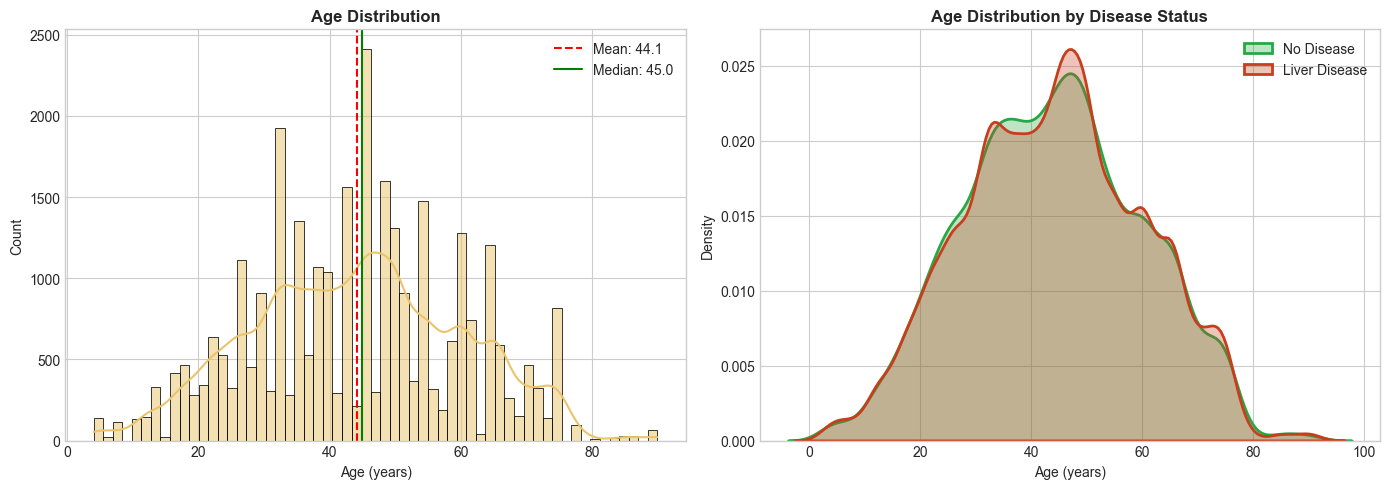


📊 Age Statistics:
   Overall: Mean=44.1, Median=45.0, Range=4.0-90.0
   No Disease: Mean=44.0, Median=45.0
   Liver Disease: Mean=44.2, Median=45.0


In [15]:
# ============================================================================
# AGE DISTRIBUTION
# ============================================================================

print("📊 AGE DISTRIBUTION")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
ax1 = axes[0]
sns.histplot(df['Age'], kde=True, color=COLORS['liver'], ax=ax1)
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
ax1.axvline(df['Age'].median(), color='green', linestyle='-', label=f"Median: {df['Age'].median():.1f}")
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Count')
ax1.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax1.legend()

# Age by disease status
ax2 = axes[1]
for status, label, color in [(0, 'No Disease', COLORS['success']), (1, 'Liver Disease', COLORS['danger'])]:
    data = df[df['liver_disease'] == status]['Age']
    sns.kdeplot(data, ax=ax2, label=label, color=color, linewidth=2, fill=True, alpha=0.3)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Density')
ax2.set_title('Age Distribution by Disease Status', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'age_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Age Statistics:")
print(f"   Overall: Mean={df['Age'].mean():.1f}, Median={df['Age'].median():.1f}, Range={df['Age'].min()}-{df['Age'].max()}")
for status in [0, 1]:
    label = 'No Disease' if status == 0 else 'Liver Disease'
    data = df[df['liver_disease'] == status]['Age']
    print(f"   {label}: Mean={data.mean():.1f}, Median={data.median():.1f}")

## 7. Outlier Detection


🔎 OUTLIER ANALYSIS (Method: IQR)
📊 Columns Analyzed: 9
⚠️  Total Outliers Detected: 20,222
🔴 Columns with >5% Outliers: 5


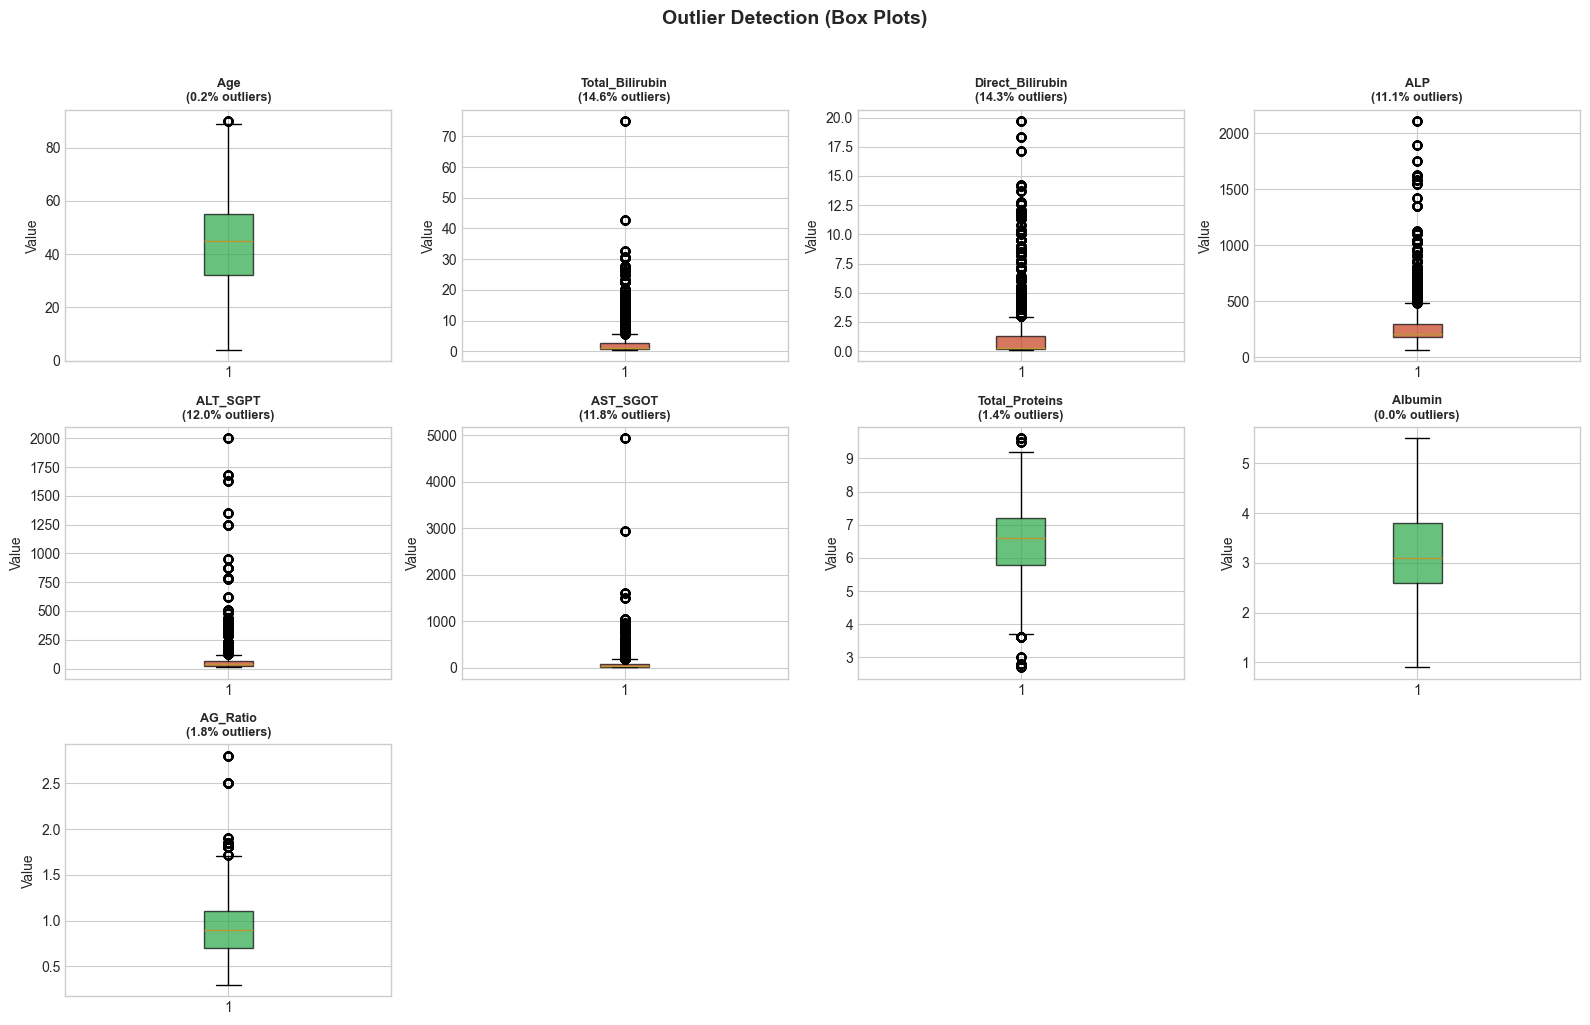


📋 Outlier Summary:


,Column,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound,Min,Max
1,Total_Bilirubin,4393,14.620,-2.050,5.550,0.400,75.000
2,Direct_Bilirubin,4316,14.320,-1.450,2.950,0.100,19.700
4,ALT_SGPT,3608,11.970,-35.500,120.500,10.000,2000.000
5,AST_SGOT,3556,11.760,-67.000,181.000,10.000,4929.000
3,ALP,3331,11.140,-9.500,482.500,63.000,2110.000
8,AG_Ratio,544,1.810,0.100,1.700,0.300,2.800
6,Total_Proteins,408,1.350,3.700,9.300,2.700,9.600
0,Age,66,0.220,-2.500,89.500,4.000,90.000
7,Albumin,0,0.000,0.800,5.600,0.900,5.500


<Figure size 640x480 with 0 Axes>

In [16]:
# ============================================================================
# OUTLIER ANALYSIS
# ============================================================================

numeric_cols = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 
                'ALT_SGPT', 'AST_SGOT', 'Total_Proteins', 'Albumin', 'AG_Ratio']

numeric_cols = [col for col in numeric_cols if col in df.columns]

outlier_stats = outlier_analysis(df, columns=numeric_cols,
                                  method='iqr', threshold=1.5, figsize=(16, 10))

plt.savefig(FIGURES_PATH / 'outliers_boxplot.png', dpi=150, bbox_inches='tight', facecolor='white')

print("\n📋 Outlier Summary:")
outlier_stats

In [17]:
# ============================================================================
# OUTLIER INVESTIGATION - ENZYME LEVELS
# ============================================================================

print("🔍 ENZYME LEVEL OUTLIER INVESTIGATION")
print("=" * 60)

# Liver enzymes can have legitimately high values in sick patients
enzyme_cols = ['ALT_SGPT', 'AST_SGOT', 'ALP']

for col in enzyme_cols:
    if col in df.columns:
        data = df[col]
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        upper_extreme = q3 + 3 * iqr  # Extreme outliers
        
        extreme_count = (data > upper_extreme).sum()
        
        # Check if extreme values are associated with disease
        extreme_disease_rate = df[data > upper_extreme]['liver_disease'].mean() * 100 if extreme_count > 0 else 0
        normal_disease_rate = df[data <= upper_extreme]['liver_disease'].mean() * 100
        
        print(f"\n{col}:")
        print(f"   Extreme outliers (>{upper_extreme:.0f}): {extreme_count} records")
        print(f"   Disease rate in extreme values: {extreme_disease_rate:.1f}%")
        print(f"   Disease rate in normal range: {normal_disease_rate:.1f}%")
        
        if extreme_disease_rate > normal_disease_rate + 10:
            print(f"   💡 High values strongly associated with disease - KEEP them!")

🔍 ENZYME LEVEL OUTLIER INVESTIGATION

ALT_SGPT:
   Extreme outliers (>179): 2245 records
   Disease rate in extreme values: 97.7%
   Disease rate in normal range: 69.4%
   💡 High values strongly associated with disease - KEEP them!

AST_SGOT:
   Extreme outliers (>274): 2296 records
   Disease rate in extreme values: 97.6%
   Disease rate in normal range: 69.3%
   💡 High values strongly associated with disease - KEEP them!

ALP:
   Extreme outliers (>667): 1692 records
   Disease rate in extreme values: 97.0%
   Disease rate in normal range: 69.9%
   💡 High values strongly associated with disease - KEEP them!


## 8. Correlation Analysis


🔗 CORRELATION ANALYSIS (Method: PEARSON)
⚠️  Highly Correlated Pairs (|r| > 0.7): 3
   • Total_Bilirubin ↔ Direct_Bilirubin: 0.887
   • ALT_SGPT ↔ AST_SGOT: 0.783
   • Total_Proteins ↔ Albumin: 0.776

🎯 Top 5 Features Correlated with liver_disease:
   • Direct_Bilirubin: +0.250
   • Total_Bilirubin: +0.225
   • ALP: +0.183
   • ALT_SGPT: +0.166
   • Albumin: -0.160


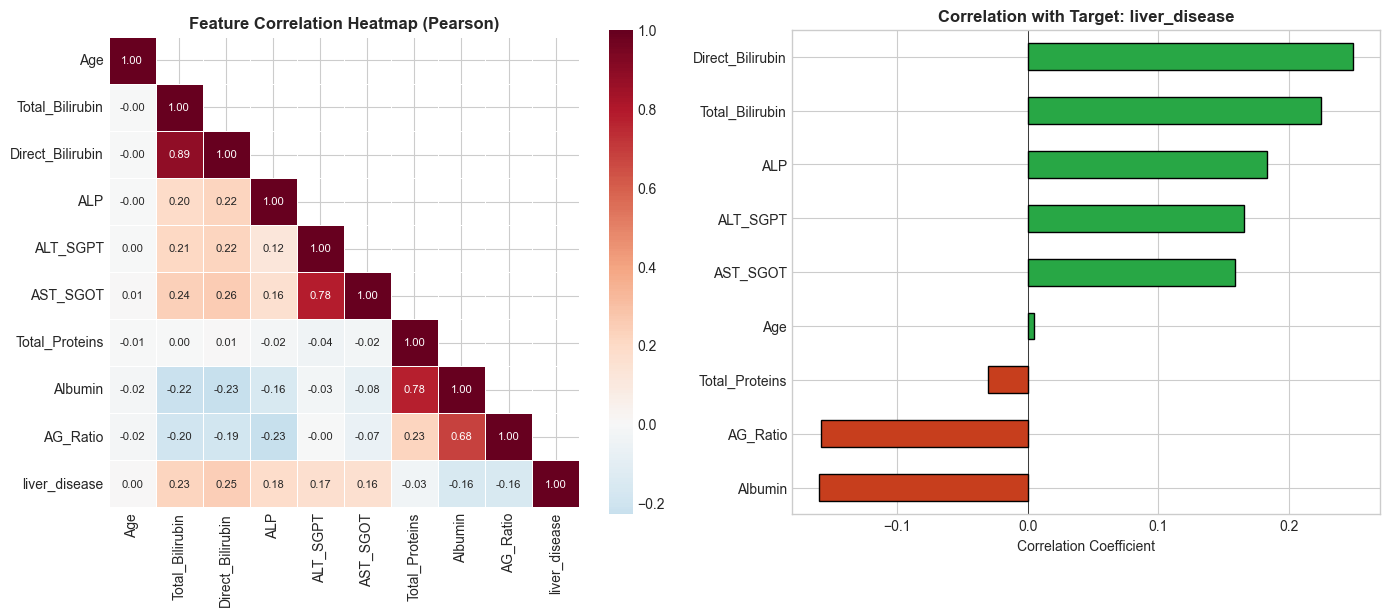

<Figure size 640x480 with 0 Axes>

In [18]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# Select numeric columns for correlation
corr_cols = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 
             'ALT_SGPT', 'AST_SGOT', 'Total_Proteins', 'Albumin', 'AG_Ratio', 'liver_disease']

corr_cols = [col for col in corr_cols if col in df.columns]

corr_matrix = correlation_analysis(df[corr_cols], target_col='liver_disease', 
                                    method='pearson', figsize=(14, 6))

plt.savefig(FIGURES_PATH / 'correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')

🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)


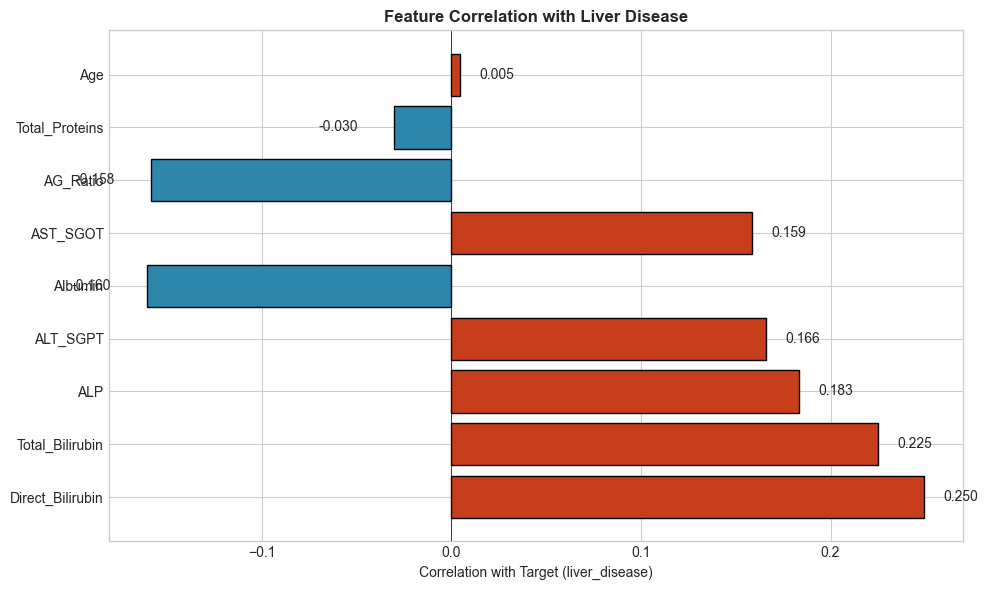


📊 Features Ranked by Correlation with Liver Disease:
   1. Direct_Bilirubin: 0.2495 (↑ Higher in disease)
   2. Total_Bilirubin: 0.2251 (↑ Higher in disease)
   3. ALP: 0.1834 (↑ Higher in disease)
   4. ALT_SGPT: 0.1659 (↑ Higher in disease)
   5. Albumin: -0.1603 (↓ Lower in disease)
   6. AST_SGOT: 0.1587 (↑ Higher in disease)
   7. AG_Ratio: -0.1584 (↓ Lower in disease)
   8. Total_Proteins: -0.0304 (↓ Lower in disease)
   9. Age: 0.0048 (↑ Higher in disease)


In [19]:
# ============================================================================
# FEATURE IMPORTANCE (CORRELATION WITH TARGET)
# ============================================================================

print("🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)")
print("=" * 60)

target_correlations = corr_matrix['liver_disease'].drop('liver_disease').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS['danger'] if c > 0 else COLORS['primary'] for c in target_correlations.values]
bars = ax.barh(target_correlations.index, target_correlations.values, color=colors, edgecolor='black')
ax.set_xlabel('Correlation with Target (liver_disease)')
ax.set_title('Feature Correlation with Liver Disease', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

for bar, corr in zip(bars, target_correlations.values):
    x_pos = corr + 0.01 if corr > 0 else corr - 0.04
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{corr:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'feature_importance_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Features Ranked by Correlation with Liver Disease:")
for idx, (feat, corr) in enumerate(target_correlations.items(), 1):
    direction = "↑ Higher in disease" if corr > 0 else "↓ Lower in disease"
    print(f"   {idx}. {feat}: {corr:.4f} ({direction})")

## 9. Feature vs Target Analysis

📊 LIVER FUNCTION TESTS BY DISEASE STATUS


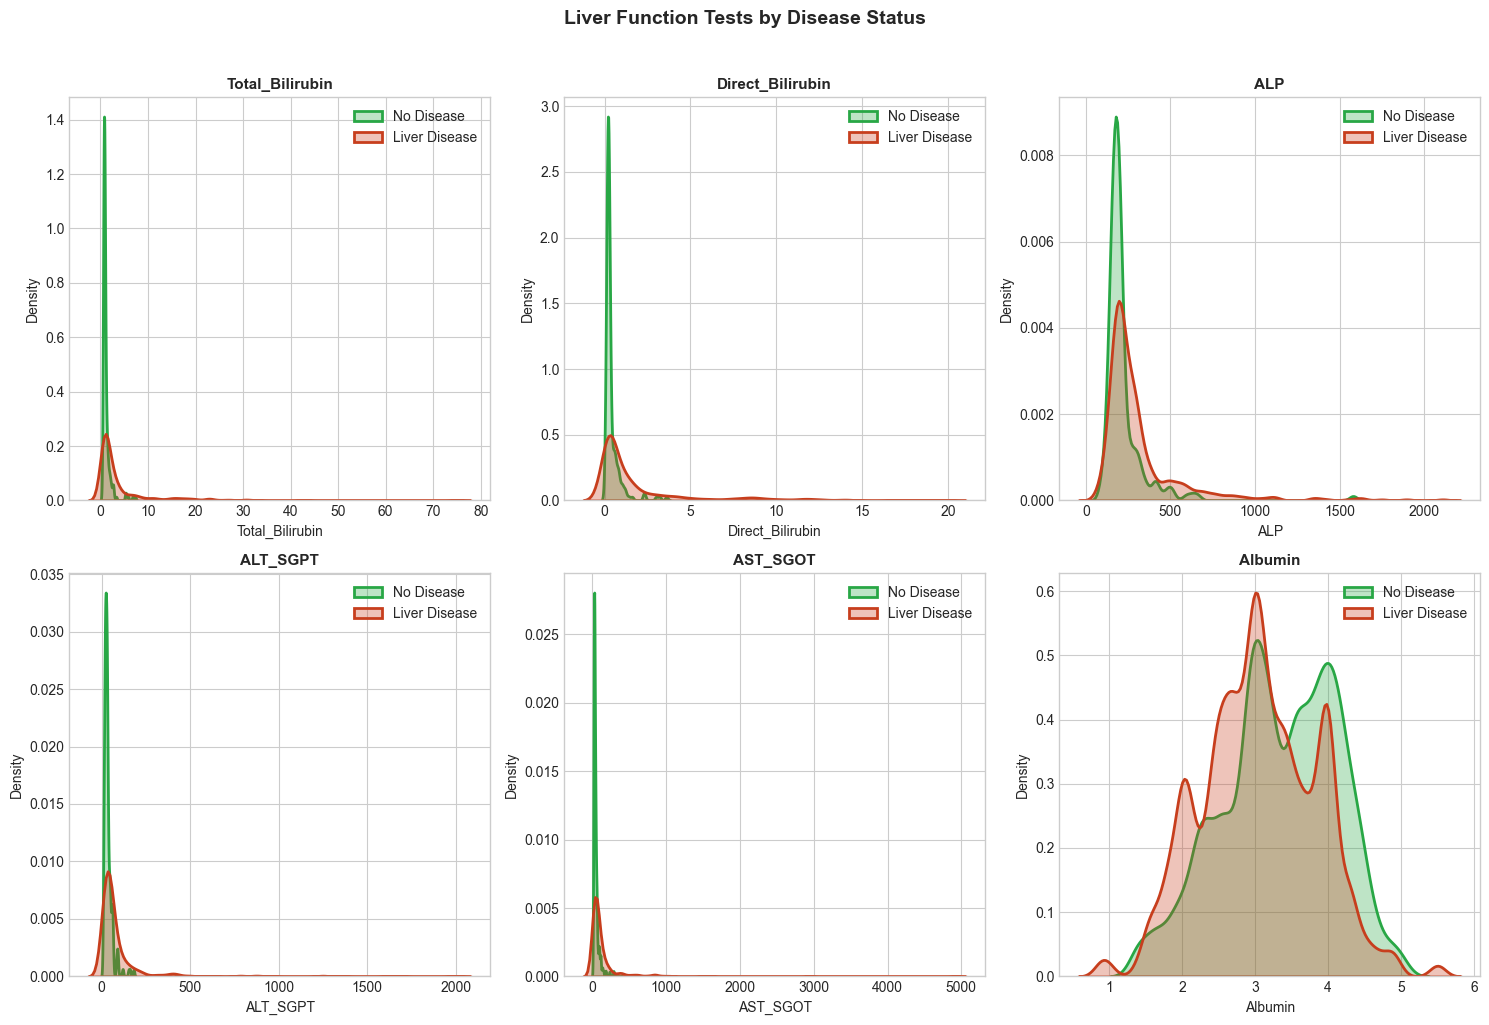

In [20]:
# ============================================================================
# LFT VALUES BY DISEASE STATUS
# ============================================================================

print("📊 LIVER FUNCTION TESTS BY DISEASE STATUS")
print("=" * 60)

lft_cols = ['Total_Bilirubin', 'Direct_Bilirubin', 'ALP', 'ALT_SGPT', 
            'AST_SGOT', 'Albumin']

lft_cols = [col for col in lft_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(lft_cols):
    ax = axes[idx]
    
    for status, label, color in [(0, 'No Disease', COLORS['success']), 
                                  (1, 'Liver Disease', COLORS['danger'])]:
        data = df[df['liver_disease'] == status][col].dropna()
        sns.kdeplot(data, ax=ax, label=label, color=color, linewidth=2, fill=True, alpha=0.3)
    
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Liver Function Tests by Disease Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'lft_by_target.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

📊 AST/ALT RATIO (De Ritis Ratio) ANALYSIS

De Ritis Ratio (AST/ALT):
   < 1: Suggests viral hepatitis, NAFLD
   > 1: Suggests alcoholic liver disease, cirrhosis
   > 2: Strongly suggests alcoholic liver disease


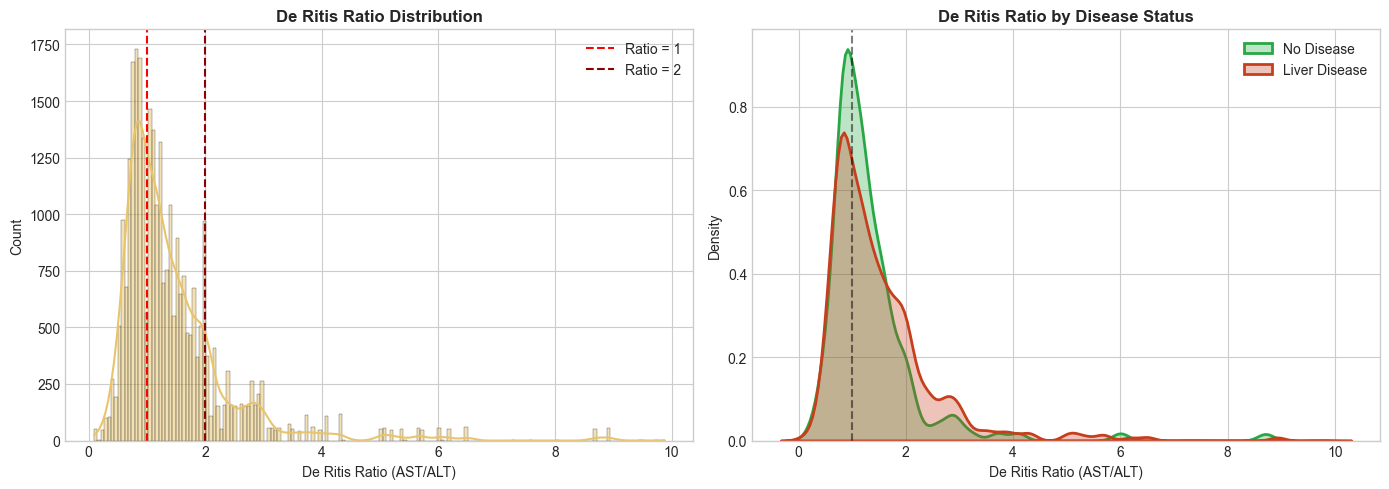


📊 De Ritis Ratio Statistics:
   Overall Mean: 1.49
   No Disease Mean: 1.33
   Liver Disease Mean: 1.55

💡 RECOMMENDATION: Create De Ritis Ratio as a derived feature!


In [21]:
# ============================================================================
# AST/ALT RATIO (DE RITIS RATIO) - CLINICAL DIAGNOSTIC MARKER
# ============================================================================

print("📊 AST/ALT RATIO (De Ritis Ratio) ANALYSIS")
print("=" * 60)

if 'AST_SGOT' in df.columns and 'ALT_SGPT' in df.columns:
    # De Ritis Ratio = AST/ALT
    # < 1: Viral hepatitis, non-alcoholic fatty liver
    # > 1: Alcoholic liver disease, cirrhosis
    # > 2: Strongly suggests alcoholic liver disease
    
    df['DeRitis_Ratio'] = df['AST_SGOT'] / df['ALT_SGPT'].replace(0, np.nan)
    
    print("\nDe Ritis Ratio (AST/ALT):")
    print("   < 1: Suggests viral hepatitis, NAFLD")
    print("   > 1: Suggests alcoholic liver disease, cirrhosis")
    print("   > 2: Strongly suggests alcoholic liver disease")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution
    ax1 = axes[0]
    valid_ratio = df['DeRitis_Ratio'].dropna()
    valid_ratio = valid_ratio[(valid_ratio > 0) & (valid_ratio < 10)]  # Filter extreme values
    sns.histplot(valid_ratio, kde=True, color=COLORS['liver'], ax=ax1)
    ax1.axvline(1, color='red', linestyle='--', label='Ratio = 1')
    ax1.axvline(2, color='darkred', linestyle='--', label='Ratio = 2')
    ax1.set_xlabel('De Ritis Ratio (AST/ALT)')
    ax1.set_ylabel('Count')
    ax1.set_title('De Ritis Ratio Distribution', fontsize=12, fontweight='bold')
    ax1.legend()
    
    # By disease status
    ax2 = axes[1]
    for status, label, color in [(0, 'No Disease', COLORS['success']), 
                                  (1, 'Liver Disease', COLORS['danger'])]:
        data = df[df['liver_disease'] == status]['DeRitis_Ratio'].dropna()
        data = data[(data > 0) & (data < 10)]
        sns.kdeplot(data, ax=ax2, label=label, color=color, linewidth=2, fill=True, alpha=0.3)
    ax2.axvline(1, color='black', linestyle='--', alpha=0.5)
    ax2.set_xlabel('De Ritis Ratio (AST/ALT)')
    ax2.set_title('De Ritis Ratio by Disease Status', fontsize=12, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'deritis_ratio.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\n📊 De Ritis Ratio Statistics:")
    print(f"   Overall Mean: {df['DeRitis_Ratio'].mean():.2f}")
    print(f"   No Disease Mean: {df[df['liver_disease']==0]['DeRitis_Ratio'].mean():.2f}")
    print(f"   Liver Disease Mean: {df[df['liver_disease']==1]['DeRitis_Ratio'].mean():.2f}")
    
    print("\n💡 RECOMMENDATION: Create De Ritis Ratio as a derived feature!")

## 10. Summary & Preprocessing Recommendations

In [22]:
# ============================================================================
# EDA SUMMARY
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  🫁 LIVER DISEASE DATASET - EDA SUMMARY".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Total Features: {len(df.columns)} (including derived)")
print(f"   • Original Features: 11 (compact but informative)")
print(f"   • Target Column: 'Result' (1=Disease, 2=No Disease)")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✅ DATA QUALITY FINDINGS:")
missing_total = df.isnull().sum().sum()
print(f"   • Missing Values: {missing_total}")
print(f"   • Duplicate Records: {df.duplicated().sum()}")

class_0 = (df['liver_disease'] == 0).sum()
class_1 = (df['liver_disease'] == 1).sum()
print(f"   • Class Balance: {class_0/len(df)*100:.1f}% (No Disease) / {class_1/len(df)*100:.1f}% (Disease)")
print(f"   • Imbalance Ratio: {max(class_0, class_1) / min(class_0, class_1):.2f}:1")

print("\n⚠️ DATA ISSUES IDENTIFIED:")
print(f"   • Target encoding non-standard (1=Disease, 2=No Disease)")
print(f"   • High outliers in enzyme values (but clinically meaningful)")
print(f"   • Gender imbalance ({gender_counts.to_dict()})")

print("\n📈 KEY INSIGHTS:")
print(f"   • Direct bilirubin most correlated with liver disease")
print(f"   • Albumin and A/G ratio inversely correlated (lower in disease)")
print(f"   • Males have higher disease rate than females")
print(f"   • De Ritis ratio (AST/ALT) is a useful derived feature")



╔════════════════════════════════════════════════════════════════════╗
║  🫁 LIVER DISEASE DATASET - EDA SUMMARY                            ║
╚════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Records: 30,691
   • Total Features: 13 (including derived)
   • Original Features: 11 (compact but informative)
   • Target Column: 'Result' (1=Disease, 2=No Disease)
   • Memory Usage: 4.59 MB

✅ DATA QUALITY FINDINGS:
   • Missing Values: 6280
   • Duplicate Records: 11323
   • Class Balance: 28.6% (No Disease) / 71.4% (Disease)
   • Imbalance Ratio: 2.50:1

⚠️ DATA ISSUES IDENTIFIED:
   • Target encoding non-standard (1=Disease, 2=No Disease)
   • High outliers in enzyme values (but clinically meaningful)
   • Gender imbalance ({'Male': 21986, 'Female': 7803})

📈 KEY INSIGHTS:
   • Direct bilirubin most correlated with liver disease
   • Albumin and A/G ratio inversely correlated (lower in disease)
   • Males have higher disease rate than f

In [23]:
# ============================================================================
# PREPROCESSING RECOMMENDATIONS FOR WEEK 3
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

recommendations = """
1. TARGET ENCODING FIX:
   ✓ Convert Result: 1 → 1 (Disease), 2 → 0 (No Disease)
   ✓ Standard: 0 = Negative, 1 = Positive

2. FEATURE ENGINEERING:
   ✓ Create De Ritis Ratio = AST_SGOT / ALT_SGPT
   ✓ Create Indirect_Bilirubin = Total - Direct
   ✓ Create Globulin = Total_Proteins - Albumin
   ✓ Age groups: Young (<30), Adult (30-50), Senior (>50)

3. ENCODING:
   ✓ Gender: Male=1, Female=0 (binary encoding)

4. FEATURE SCALING:
   ✓ StandardScaler for all LFT values
   ✓ Enzyme values have wide ranges

5. OUTLIER HANDLING:
   ✓ DON'T remove high enzyme values - clinically meaningful!
   ✓ Consider log transformation for highly skewed features
   ✓ Winsorization for extreme outliers (cap at 99th percentile)

6. MISSING VALUE HANDLING:
   ✓ Check A/G Ratio for missing (division by zero issues)
   ✓ Median imputation for numeric columns

7. CLASS BALANCE:
   ✓ Classes are fairly balanced - may not need SMOTE
   ✓ Use stratified splits

8. SCHEMA ALIGNMENT (for unified dataset):
   ✓ Age → age
   ✓ Gender → gender (encode consistently)
   ✓ Liver-specific features: bilirubin, ALT, AST, ALP, albumin, AG_ratio
   ✓ Rename columns to match unified schema
"""

print(recommendations)



╔════════════════════════════════════════════════════════════════════╗
║  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)                         ║
╚════════════════════════════════════════════════════════════════════╝

1. TARGET ENCODING FIX:
   ✓ Convert Result: 1 → 1 (Disease), 2 → 0 (No Disease)
   ✓ Standard: 0 = Negative, 1 = Positive

2. FEATURE ENGINEERING:
   ✓ Create De Ritis Ratio = AST_SGOT / ALT_SGPT
   ✓ Create Indirect_Bilirubin = Total - Direct
   ✓ Create Globulin = Total_Proteins - Albumin
   ✓ Age groups: Young (<30), Adult (30-50), Senior (>50)

3. ENCODING:
   ✓ Gender: Male=1, Female=0 (binary encoding)

4. FEATURE SCALING:
   ✓ StandardScaler for all LFT values
   ✓ Enzyme values have wide ranges

5. OUTLIER HANDLING:
   ✓ DON'T remove high enzyme values - clinically meaningful!
   ✓ Consider log transformation for highly skewed features
   ✓ Winsorization for extreme outliers (cap at 99th percentile)

6. MISSING VALUE HANDLING:
   ✓ Check A/G Ratio for missing (divis

In [24]:
# ============================================================================
# SAVE EDA SUMMARY TO FILE
# ============================================================================

summary_dict = {
    'dataset': 'Liver Disease (Indian Liver Patient Dataset Extended)',
    'rows': len(df),
    'columns': 11,
    'target_column': 'Result (1=Disease, 2=No Disease)',
    'missing_values': int(df.isnull().sum().sum()),
    'duplicate_records': int(df.duplicated().sum()),
    'class_balance': f"{(df['liver_disease']==0).mean()*100:.1f}% / {(df['liver_disease']==1).mean()*100:.1f}%",
    'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    'top_correlations': target_correlations.to_dict(),
    'key_findings': [
        'Compact dataset with 11 features',
        'Direct bilirubin most predictive',
        'Albumin and A/G ratio inversely related to disease',
        'De Ritis ratio useful as derived feature',
        'Male patients have higher disease rate'
    ],
    'preprocessing_notes': [
        'Fix target encoding (1=Disease, 2=No Disease → 0,1)',
        'Create derived features (De Ritis ratio, indirect bilirubin)',
        'Log transform for skewed enzyme values',
        'Do NOT remove outliers - clinically meaningful'
    ]
}

import json
with open(FIGURES_PATH / 'eda_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

print(f"\n📁 EDA Summary saved to: {FIGURES_PATH / 'eda_summary.json'}")
print("\n✅ Liver Disease EDA Complete!")


📁 EDA Summary saved to: figures\liver_disease\eda_summary.json

✅ Liver Disease EDA Complete!


---

## 📋 Next Steps

1. **Week 2 Final:** Create cross-disease comparison report
2. **Week 3:** Implement preprocessing recommendations
3. **Week 3-4:** Create unified schema for multi-disease fusion

---

**Notebook Complete** | BTP 2025-2026 | IIIT Sri City